# Проект: Поиск референсных изображений по текстовому описанию (PoC)

## Цель проекта
Разработка демонстрационной версии (Proof of Concept) поискового сервиса для фотохостинга.
Сервис должен находить изображения, наиболее соответствующие текстовому запросу пользователя, выдавая оценку схожести от 0 до 1.

## Основные задачи
1. **Подготовка данных**: Агрегация экспертных и краудсорсинговых оценок, очистка от запрещенного контента.
2. **Векторизация**:
   - Изображения: Использование предобученной CNN (ResNet50).
   - Текст: Векторизация через TF-IDF / Word2Vec / BERT.
3. **Обучение модели**: Построение регрессионной модели (Linear Regression / MLP) с подбором гиперпараметров для предсказания оценки соответствия.
4. **Тестирование**: Демонстрация работы поиска на тестовых запросах с учетом юридических ограничений.

## Юридические ограничения
Согласно законодательству ряда стран, сервис запрещает обработку контента с изображением или описанием детей (лиц младше 16 лет) без согласия представителей.
- **Решение в PoC**:
  - Исключение таких пар (изображение-текст) из обучающей выборки.
  - Возврат дисклеймера при поисковом запросе, содержащем ключевые слова, указывающие на детей.

## Импорт библиотек

In [1]:
import os
import re
import gc
import random
import warnings

# игнорируем предупреждения для чистоты вывода
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV, GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import Normalizer, normalize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from transformers import BertTokenizer, BertModel

import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

from tqdm import tqdm


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# скачиваем необходимые ресурсы NLTK (делается один раз)
#try:
#    nltk.data.find('corpora/wordnet')
#    nltk.data.find('taggers/averaged_perceptron_tagger')
#except LookupError:
#    nltk.download('wordnet')
#    nltk.download('averaged_perceptron_tagger')
#    nltk.download('omw-1.4')

In [2]:
# Проверка доступности GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Внимание: GPU не найден. Обучение будет проходить на CPU (медленнее).")

Используемое устройство: cuda
GPU: NVIDIA GeForce RTX 3060


## Функции

In [3]:
def info_df(df):
    """
    Выводит:
    - информацию о DataFrame,
    - количество и распределение пропущенных значений,
    - количество явных дубликатов,
    - первые пять строк DataFrame.
    """
    print("Общая инфо:")
    df.info()

    print("\nПроверка на наличие пропусков:")
    null_values = df.isnull().sum()
    if null_values.sum() > 0:
            print("В датафрейме есть пропущенные значения:")
            display(null_values)
    else:
        print("Пропусков нет.")

    print("\nПроверка на наличие дубликатов:")
    duplicates = df.duplicated().sum()
    if duplicates > 0:
        print(f"В датафрейме найдено {duplicates} явных дубликатов.")
    else:
        print("Явные дубликаты в датафрейме отсутствуют.")

In [4]:
def plot_random_images(img_dir, df_source, n_samples=15, title_prefix=""):
    """
    Функция для отображения случайных изображений.
    img_dir: путь к папке с картинками
    df_source: датафрейм, откуда брать имена файлов (df_train или df_test)
    n_samples: количество картинок для показа
    """
    # проверяем существование папки
    if not os.path.exists(img_dir):
        print(f"Папка {img_dir} не найдена! Проверьте путь.")
        return

    # получаем список уникальных имен файлов из датасета
    # в df_train колонка 'image', в df_test тоже обычно 'image' (проверим)
    col_name = 'image' if 'image' in df_source.columns else df_source.columns[0]
    unique_images = df_source[col_name].unique()

    # если картинок меньше, чем хотим показать, берем все
    k = min(n_samples, len(unique_images))
    selected_images = random.sample(list(unique_images), k)

    # настройка графика
    fig, axes = plt.subplots(3, 5, figsize=(20, 12))
    axes = axes.flatten()

    print(f"️ Отображаем {k} случайных изображений из {title_prefix}...")

    for i, img_name in enumerate(selected_images):
        img_path = os.path.join(img_dir, img_name)

        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].axis('off')
            # подпись с именем файла (обрезаем длинное имя)
            axes[i].set_title(f"{img_name[:20]}...", fontsize=8, color='blue')
        except FileNotFoundError:
            axes[i].text(0.5, 0.5, f"File not found:\n{img_name}",
                         ha='center', va='center', fontsize=8, color='red')
            axes[i].axis('off')
        except Exception as e:
            axes[i].text(0.5, 0.5, f"Error:\n{str(e)}",
                         ha='center', va='center', fontsize=8, color='orange')
            axes[i].axis('off')

    # скрываем пустые подграфики, если картинок меньше 15
    for j in range(k, 15):
        axes[j].axis('off')

    plt.suptitle(f"Случайные примеры: {title_prefix}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

In [5]:
# агрегация оценок
def get_total_vote(data,
                    expert_w=0.9,
                    crowd_w=0.1):
    """
    Функция для объединения признаков экспертов и краудсорсинга
    """
    expert = data['target_expert']
    crowd = data['ratio']

    # если есть обе оценки, объединяем
    if not pd.isna(expert) and not pd.isna(crowd):
        return expert_w * expert + crowd_w * crowd
    # если есть только экспертная оценка
    elif not pd.isna(expert):
        return expert
    # если есть только оценка краудсорсинга
    elif not pd.isna(crowd):
        return crowd
    # если оценок вообще нет
    else:
        return np.nan

In [6]:
def get_bert_extractor(device, model_name='bert-base-uncased'):
    """Возвращает готовую модель BERT и токенизатор"""
    print(f"Загрузка модели {model_name}...")
    tokenizer = BertTokenizer.from_pretrained(model_name)
    model = BertModel.from_pretrained(model_name).to(device)

    # замораживаем веса
    for param in model.parameters():
        param.requires_grad = False

    model.eval()
    return model, tokenizer

In [7]:
def get_text_embeddings(df, model, tokenizer, device,
                        text_col='query_text', id_col='query_id',
                        cache_prefix='bert_features'):
    """
    df: DataFrame с текстами
    model, tokenizer: объекты из get_bert_extractor
    cache_prefix: Префикс для имен файлов кэша
    """
    # формируем имена файлов кэша
    cache_pt = f"{cache_prefix}_embs.pt"
    cache_txt = f"{cache_prefix}_ids.txt"

    current_ids = df[id_col].astype(str).tolist()

    # проверка кэша
    if os.path.exists(cache_pt) and os.path.exists(cache_txt):
        try:
            print(f"Загрузка кэша: {cache_pt}")
            embs = torch.load(cache_pt, map_location=device)

            with open(cache_txt, "r", encoding="utf-8") as f:
                cached_ids = f.read().splitlines()

            # простая проверка: если списки ID идентичны, используем кэш
            if cached_ids == current_ids:
                return embs, current_ids
            else:
                raise ValueError("IDs не совпадают")

        except Exception as e:
            print(f"Кэш битый или неактуальный ({e}), удаляю...")
            if os.path.exists(cache_pt): os.remove(cache_pt)
            if os.path.exists(cache_txt): os.remove(cache_txt)

    # генерация
    texts = df[text_col].astype(str).tolist()

    # токенизация
    tokenized = tokenizer(
        texts,
        add_special_tokens=True,
        max_length=128,
        truncation=True,
        padding=True,
        return_tensors='pt'
    )

    input_ids = tokenized['input_ids'].to(device)
    attention_mask = tokenized['attention_mask'].to(device)

    all_embs = []
    batch_size = 32

    with torch.no_grad():
        for i in tqdm(range(0, input_ids.size(0), batch_size), desc="BERT Inference"):
            ids_batch = input_ids[i : i + batch_size]
            mask_batch = attention_mask[i : i + batch_size]

            outputs = model(input_ids=ids_batch, attention_mask=mask_batch)

            cls_emb = outputs.last_hidden_state[:, 0, :]
            all_embs.append(cls_emb.cpu())

    final_embs = torch.cat(all_embs, dim=0)

    # сохранение
    torch.save(final_embs, cache_pt)
    with open(cache_txt, "w", encoding="utf-8") as f:
        f.write("\n".join(current_ids))

    print(f"Готово. Сохранено в {cache_pt}")
    return final_embs, current_ids

In [8]:
class ImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        # читаем файлы
        valid_ext = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp')
        self.file_names = sorted([
            f for f in os.listdir(root_dir)
            if f.lower().endswith(valid_ext)
        ])

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        img_name = self.file_names[idx]
        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, img_name

def get_resnet_extractor(device):
    """Возвращает готовую модель и трансформы"""
    # модель
    resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in resnet.parameters():
        param.requires_grad = False
    # убираем последний слой
    model = nn.Sequential(*list(resnet.children())[:-1]).to(device)
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    return model, transform

In [9]:
def get_image_embeddings(image_dir, model, transform, device, cache_prefix):
    """
    image_dir: Путь к папке с картинками
    cache_prefix: Префикс для имен файлов кэша (например 'train' или 'test')
    """
    # формируем имена файлов кэша автоматически
    cache_pt = f"{cache_prefix}_embs.pt"
    cache_txt = f"{cache_prefix}_names.txt"

    # проверка кэша
    if os.path.exists(cache_pt) and os.path.exists(cache_txt):
        try:
            print(f"Загрузка кэша: {cache_pt}")
            embs = torch.load(cache_pt, map_location=device)
            with open(cache_txt, "r") as f:
                names = f.read().splitlines()
            if embs.shape[1] == 512:
                return embs, names
            else:
                raise ValueError("Bad shape")
        except:
            print("Кэш битый, удаляю...")
            if os.path.exists(cache_pt): os.remove(cache_pt)
            if os.path.exists(cache_txt): os.remove(cache_txt)

    # генерация
    # создаем датасет
    dataset = ImageDataset(root_dir=image_dir, transform=transform)
    loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)

    all_embs = []
    all_names = []

    with torch.no_grad():
        for imgs, names in tqdm(loader):
            imgs = imgs.to(device)
            feats = model(imgs).squeeze() # [B, 512]
            all_embs.append(feats.cpu())
            all_names.extend(names)

    final_embs = torch.cat(all_embs, dim=0)

    # сохранение
    torch.save(final_embs, cache_pt)
    with open(cache_txt, "w") as f:
        f.write("\n".join(all_names))

    print(f"Готово. Сохранено в {cache_pt}")
    return final_embs, all_names

In [10]:
def create_image_embedding_dict(embs_tensor, names_list, normalize=True):
    """
    Создает словарь из тензора и списка имен.
    """
    # переводим в CPU и NumPy
    embs_np = embs_tensor.detach().cpu().numpy()

    # опционально: L2 нормализация
    if normalize:
        normalizer = Normalizer(norm='l2')
        embs_np = normalizer.fit_transform(embs_np)

    # создаем словарь
    emb_dict = {name: vec for name, vec in zip(names_list, embs_np)}
    return emb_dict

In [11]:
def get_single_text_embedding(text, model, tokenizer, device):
    """
    Векторизует одну строку текста через BERT.
    Возвращает нормализованный torch.Tensor [1, 768]
    """
    inputs = tokenizer(
        [text],  # передаем как список
        add_special_tokens=True,
        max_length=128,      # Должно совпадать с get_text_embeddings
        truncation=True,
        padding=True,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        emb = outputs.last_hidden_state[:, 0, :] # [1, 768]

    return emb

# Загрузка данных

In [12]:
DATA_DIR = 'data'

# пути к файлам
train_dataset_path = os.path.join(DATA_DIR, 'train_dataset.csv')
crowd_path = os.path.join(DATA_DIR, 'CrowdAnnotations.tsv')
expert_path = os.path.join(DATA_DIR, 'ExpertAnnotations.tsv')
test_queries_path = os.path.join(DATA_DIR, 'test_queries.csv')

In [13]:
try:
    df_train = pd.read_csv(train_dataset_path, decimal=',')
    df_crowd = pd.read_csv(crowd_path, delimiter='\t', header=None,
                           names=['image', 'query_id', 'ratio', 'count_yes', 'count_no'])
    df_expert = pd.read_csv(expert_path, delimiter='\t', header=None,
                            names=['image', 'query_id', 'Expert1', 'Expert2', 'Expert3'])
    df_test = pd.read_csv(test_queries_path, delimiter='|')

    print("Данные успешно загружены")
    print(f"Train: {df_train.shape}, Expert: {df_expert.shape}")

except Exception as e:
    # просто выводим текст ошибки
    print(f"Ошибка при загрузке: {e}")

Данные успешно загружены
Train: (5822, 3), Expert: (5822, 5)


In [14]:
info_df(df_train)

Общая инфо:
<class 'pandas.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   image       5822 non-null   str  
 1   query_id    5822 non-null   str  
 2   query_text  5822 non-null   str  
dtypes: str(3)
memory usage: 136.6 KB

Проверка на наличие пропусков:
Пропусков нет.

Проверка на наличие дубликатов:
Явные дубликаты в датафрейме отсутствуют.


In [15]:
df_train.head()

,image,query_id,query_text
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...


In [16]:
info_df(df_crowd)

Общая инфо:
<class 'pandas.DataFrame'>
RangeIndex: 47830 entries, 0 to 47829
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   image      47830 non-null  str    
 1   query_id   47830 non-null  str    
 2   ratio      47830 non-null  float64
 3   count_yes  47830 non-null  int64  
 4   count_no   47830 non-null  int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 1.8 MB

Проверка на наличие пропусков:
Пропусков нет.

Проверка на наличие дубликатов:
Явные дубликаты в датафрейме отсутствуют.


In [17]:
df_crowd.head()

,image,query_id,ratio,count_yes,count_no
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,0.0,0,3
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,0.0,0,3
3,1056338697_4f7d7ce270.jpg,2073964624_52da3a0fc4.jpg#2,0.0,0,3
4,1056338697_4f7d7ce270.jpg,2083434441_a93bc6306b.jpg#2,0.0,0,3


In [18]:
info_df(df_expert)

Общая инфо:
<class 'pandas.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   image     5822 non-null   str  
 1   query_id  5822 non-null   str  
 2   Expert1   5822 non-null   int64
 3   Expert2   5822 non-null   int64
 4   Expert3   5822 non-null   int64
dtypes: int64(3), str(2)
memory usage: 227.6 KB

Проверка на наличие пропусков:
Пропусков нет.

Проверка на наличие дубликатов:
Явные дубликаты в датафрейме отсутствуют.


In [19]:
df_expert.head()

,image,query_id,Expert1,Expert2,Expert3
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1,2,2
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1,1,2


In [20]:
info_df(df_test)

Общая инфо:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  500 non-null    int64
 1   query_id    500 non-null    str  
 2   query_text  500 non-null    str  
 3   image       500 non-null    str  
dtypes: int64(1), str(3)
memory usage: 15.8 KB

Проверка на наличие пропусков:
Пропусков нет.

Проверка на наличие дубликатов:
Явные дубликаты в датафрейме отсутствуют.


In [21]:
df_test.head()

,Unnamed: 0,query_id,query_text,image
0,0,1177994172_10d143cb8d.jpg#0,"Two blonde boys , one in a camouflage shirt an...",1177994172_10d143cb8d.jpg
1,1,1177994172_10d143cb8d.jpg#1,Two boys are squirting water guns at each other .,1177994172_10d143cb8d.jpg
2,2,1177994172_10d143cb8d.jpg#2,Two boys spraying each other with water,1177994172_10d143cb8d.jpg
3,3,1177994172_10d143cb8d.jpg#3,Two children wearing jeans squirt water at eac...,1177994172_10d143cb8d.jpg
4,4,1177994172_10d143cb8d.jpg#4,Two young boys are squirting water at each oth...,1177994172_10d143cb8d.jpg


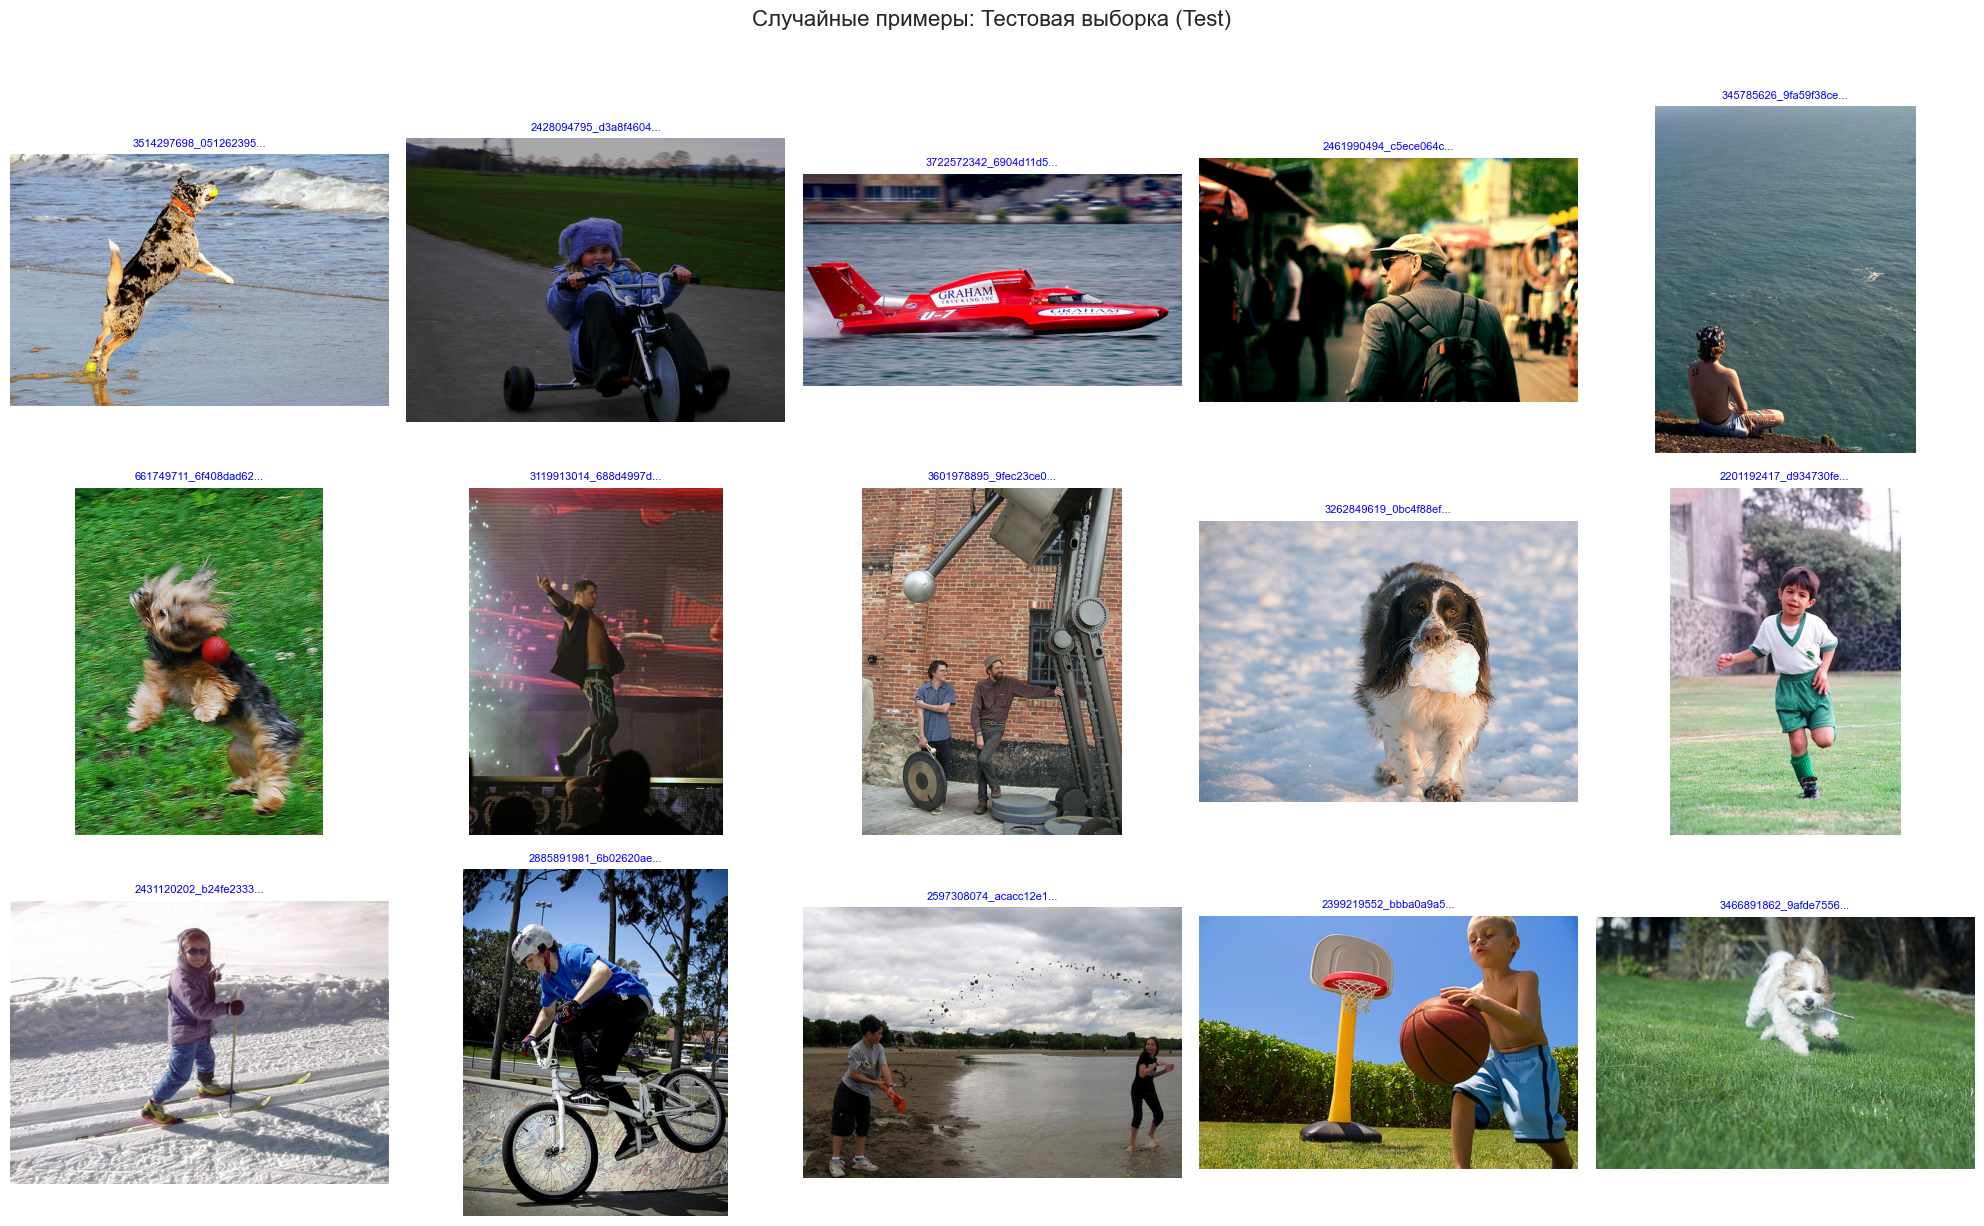

In [22]:
TRAIN_IMG_DIR = 'data/train_images'
TEST_IMG_DIR = 'data/test_images'

if 'df_train' in locals() and 'df_test' in locals():
    plot_random_images(TRAIN_IMG_DIR, df_train, n_samples=15, title_prefix="Обучающая выборка (Train)")
    plot_random_images(TEST_IMG_DIR, df_test, n_samples=15, title_prefix="Тестовая выборка (Test)")
else:
    print("Ошибка: Датафреймы df_train или df_test еще не загружены. Выполните ячейку загрузки данных.")

## Вывод

Данные загружены, пропусков и дубликатов нет. Данные соответствуют описанию.

# Исследовательский анализ данных

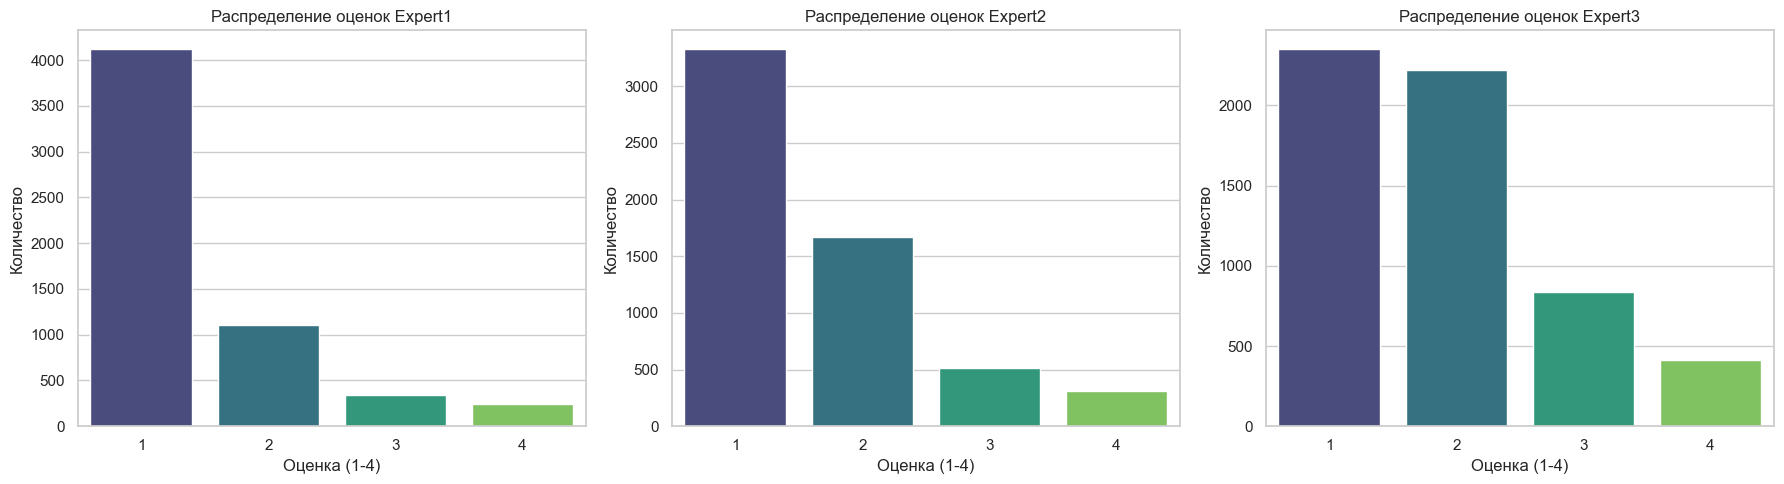

In [23]:
# распределение индивидуальных оценок каждого эксперта
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['Expert1', 'Expert2', 'Expert3']):
    sns.countplot(data=df_expert, x=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Распределение оценок {col}')
    axes[i].set_xlabel('Оценка (1-4)')
    axes[i].set_ylabel('Количество')
plt.tight_layout()
plt.show()

In [24]:
# статистика согласованности
def check_agreement(row):
    votes = [row['Expert1'], row['Expert2'], row['Expert3']]
    if len(set(votes)) == 1: return 'Полное согласие (3/3)'
    elif len(set(votes)) == 2: return 'Частичное согласие (2/3)'
    else: return 'Разногласие (1/1/1)'

df_expert['agreement_status'] = df_expert.apply(check_agreement, axis=1)
status_counts = df_expert['agreement_status'].value_counts()

print("Статус согласованности экспертов:")
print(status_counts)
print(f"\nДоля строк с полным разногласием: {status_counts.get('Разногласие (1/1/1)', 0) / len(df_expert):.2%}")

Статус согласованности экспертов:
agreement_status
Полное согласие (3/3)       3391
Частичное согласие (2/3)    2305
Разногласие (1/1/1)          126
Name: count, dtype: int64

Доля строк с полным разногласием: 2.16%


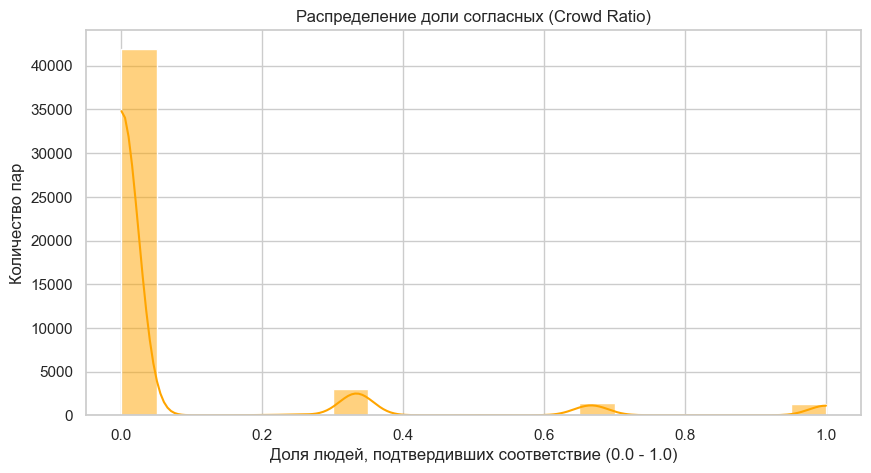

In [25]:
# анализ краудсорсинговых оценок
plt.figure(figsize=(10, 5))
sns.histplot(data=df_crowd, x='ratio', bins=20, kde=True, color='orange')
plt.title('Распределение доли согласных (Crowd Ratio)')
plt.xlabel('Доля людей, подтвердивших соответствие (0.0 - 1.0)')
plt.ylabel('Количество пар')
plt.show()

In [26]:
print(f"Средняя доля согласия в крауде: {df_crowd['ratio'].mean():.2f}")
print(f"Медианная доля согласия в крауде: {df_crowd['ratio'].median():.2f}")

Средняя доля согласия в крауде: 0.07
Медианная доля согласия в крауде: 0.00


## Вывод

1. Экспертные оценки:
- Смещение в сторону "1": Все три эксперта чаще всего ставят оценку 1.
- Разногласия: Только 2.16% строк имеют полное разногласие.
- Согласованность: В примерно 58% случаев эксперты полностью согласны. Это хороший знак надежности данных.
2. Краудсорсинговые оценки:
- Средняя доля согласия (ratio) всего 0.07, а медиана 0.00. Это значит, что в подавляющем большинстве случаев люди считали, что текст не соответствует картинке.

# Подготовка данных

Объединим оценки экспертов и краудсорсинга. Но для начала агрегируем оценку.

In [27]:
df_expert.info()

<class 'pandas.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   image             5822 non-null   str  
 1   query_id          5822 non-null   str  
 2   Expert1           5822 non-null   int64
 3   Expert2           5822 non-null   int64
 4   Expert3           5822 non-null   int64
 5   agreement_status  5822 non-null   str  
dtypes: int64(3), str(3)
memory usage: 273.0 KB


In [28]:
df_expert['target_expert'] = (
    df_expert[['Expert1', 'Expert2', 'Expert3']]
    .apply(lambda x: (x - 1) / 3)
    .mean(axis=1)
)
df_expert.head()

,image,query_id,Expert1,Expert2,Expert3,agreement_status,target_expert
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1,Полное согласие (3/3),0.000000
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2,Частичное согласие (2/3),0.111111
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2,Частичное согласие (2/3),0.111111
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1,2,2,Частичное согласие (2/3),0.222222
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1,1,2,Частичное согласие (2/3),0.111111


In [29]:
df_expert['target_expert'].describe()

count    5822.000000
mean        0.215886
std         0.268735
min         0.000000
25%         0.000000
50%         0.111111
75%         0.333333
max         1.000000
Name: target_expert, dtype: float64

In [30]:
df_crowd.info()

<class 'pandas.DataFrame'>
RangeIndex: 47830 entries, 0 to 47829
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   image      47830 non-null  str    
 1   query_id   47830 non-null  str    
 2   ratio      47830 non-null  float64
 3   count_yes  47830 non-null  int64  
 4   count_no   47830 non-null  int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 1.8 MB


In [31]:
# объединяем в один датасет
total = pd.merge(df_expert[['image', 'query_id', 'target_expert']],
                     df_crowd[['image', 'query_id', 'ratio']],
                     how='outer',
                     on=['image', 'query_id']
                    )
total.info()

<class 'pandas.DataFrame'>
RangeIndex: 51323 entries, 0 to 51322
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   image          51323 non-null  str    
 1   query_id       51323 non-null  str    
 2   target_expert  5822 non-null   float64
 3   ratio          47830 non-null  float64
dtypes: float64(2), str(2)
memory usage: 1.6 MB


In [32]:
# агрегация оценок
total['target'] = total.apply(get_total_vote, axis=1)
total.head(20)

,image,query_id,target_expert,ratio,target
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,NaN,1.000000,1.000000
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,NaN,0.000000,0.000000
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,NaN,0.000000,0.000000
3,1056338697_4f7d7ce270.jpg,2073964624_52da3a0fc4.jpg#2,NaN,0.000000,0.000000
4,1056338697_4f7d7ce270.jpg,2083434441_a93bc6306b.jpg#2,NaN,0.000000,0.000000
5,1056338697_4f7d7ce270.jpg,2204550058_2707d92338.jpg#2,NaN,0.000000,0.000000
6,1056338697_4f7d7ce270.jpg,2224450291_4c133fabe8.jpg#2,NaN,0.000000,0.000000
7,1056338697_4f7d7ce270.jpg,2248487950_c62d0c81a9.jpg#2,NaN,0.333333,0.333333
8,1056338697_4f7d7ce270.jpg,2307118114_c258e3a47e.jpg#2,NaN,0.000000,0.000000
9,1056338697_4f7d7ce270.jpg,2309860995_c2e2a0feeb.jpg#2,NaN,0.000000,0.000000


In [33]:
# удаляем лишние колонки
total.drop(columns=['target_expert', 'ratio'], inplace=True)
total.info()

<class 'pandas.DataFrame'>
RangeIndex: 51323 entries, 0 to 51322
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   image     51323 non-null  str    
 1   query_id  51323 non-null  str    
 2   target    51323 non-null  float64
dtypes: float64(1), str(2)
memory usage: 1.2 MB


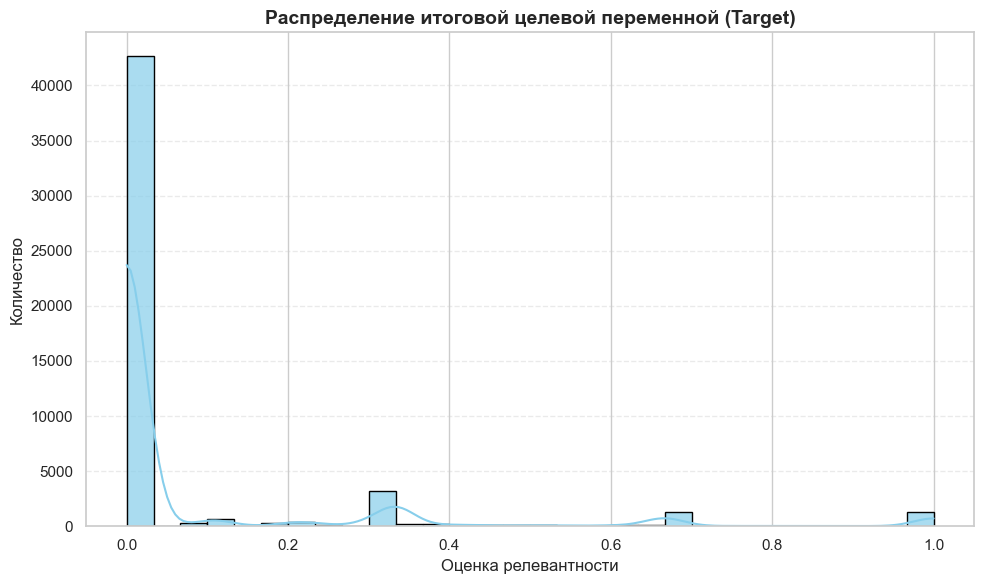

In [34]:
plt.figure(figsize=(10, 6))

# гистограмма
sns.histplot(data=total, x='target', bins=30, kde=True, color='skyblue', edgecolor='black', alpha=0.7)

# оформление
plt.title('Распределение итоговой целевой переменной (Target)', fontsize=14, fontweight='bold')
plt.xlabel('Оценка релевантности', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [35]:
total['target'].describe()

count    51323.000000
mean         0.078667
std          0.209528
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: target, dtype: float64

Пропусков нет, большинство изображений не соответствует описанию. Соберем итоговый датасет.

In [36]:
# объединяем
df_train_clean = pd.merge(df_train[['image', 'query_id', 'query_text']],
                     total[['image', 'query_id', 'target']],
                     how='outer',
                     on=['image', 'query_id']
                    )

df_train_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 51323 entries, 0 to 51322
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image       51323 non-null  str    
 1   query_id    51323 non-null  str    
 2   query_text  5822 non-null   str    
 3   target      51323 non-null  float64
dtypes: float64(1), str(3)
memory usage: 1.6 MB


In [37]:
df_train_clean.head()

,image,query_id,query_text,target
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,NaN,1.0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,NaN,0.0
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,NaN,0.0
3,1056338697_4f7d7ce270.jpg,2073964624_52da3a0fc4.jpg#2,NaN,0.0
4,1056338697_4f7d7ce270.jpg,2083434441_a93bc6306b.jpg#2,NaN,0.0


In [38]:
# убираем пропуски и дубликаты
text_mapping = df_train_clean.dropna(subset=['query_text']).drop_duplicates('query_id').set_index('query_id')['query_text']
df_train_clean['query_text'] = df_train_clean['query_text'].fillna(
    df_train_clean['query_id'].map(text_mapping)
)
df_train_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 51323 entries, 0 to 51322
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image       51323 non-null  str    
 1   query_id    51323 non-null  str    
 2   query_text  50214 non-null  str    
 3   target      51323 non-null  float64
dtypes: float64(1), str(3)
memory usage: 1.6 MB


Доля оставшихся пропусков достаточно мала, удалим их и проверим сразу на полные дубликаты.

In [39]:
df_train_clean.dropna(axis=0, inplace=True)
df_train_clean.duplicated().sum()

np.int64(0)

In [40]:
df_train_clean.info()

<class 'pandas.DataFrame'>
Index: 50214 entries, 0 to 51322
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image       50214 non-null  str    
 1   query_id    50214 non-null  str    
 2   query_text  50214 non-null  str    
 3   target      50214 non-null  float64
dtypes: float64(1), str(3)
memory usage: 1.9 MB


Датасет готов. Теперь юридическая очистка.

In [41]:
# юридическая очистка
restricted_words = [
    'baby', 'babies', 'newborn', 'infant', 'toddler',
    'child', 'children', 'kid', 'kids', 'teenager', 'teen',
    'adolescent', 'youth', 'youngster', 'minor', 'juvenile',
    'preschooler', 'schoolchild', 'schoolboy', 'schoolgirl',
    'under 16', 'under sixteen', 'minor age', 'underage',
    'son', 'daughter', 'boy', 'boys', 'girls', 'girl',
    'brother', 'sister', 'sibling',
    'grandson', 'granddaughter',
    'nephew', 'niece', 'childhood',
    'preschool', 'kindergarten', 'nursery',
    'pupil', 'classmate', 'homework', 'schoolwork', 'classroom',
    'bedtime story', 'growing up', 'underage'
]

pattern = r'\b(' + '|'.join(restricted_words) + r')\b'

# находим строки, которые попадут под удаление
# str.contains возвращает булеву маску
mask_forbidden = df_train_clean['query_text'].str.contains(pattern, case=False, na=False, regex=True)
deleted_rows = df_train_clean[mask_forbidden]
print(f"Найдено записей с запрещенным контентом: {len(deleted_rows)}")

Найдено записей с запрещенным контентом: 14276


In [42]:
# для найденных описаний берем query_id и извлекаем из них имена картинок
deleted_images = set()
for query_id in deleted_rows['query_id']:
    image_name = query_id.split('#')[0]
    deleted_images.add(image_name)

print(f"Найдено неподобающих изображений: {len(deleted_images)}")

Найдено неподобающих изображений: 289


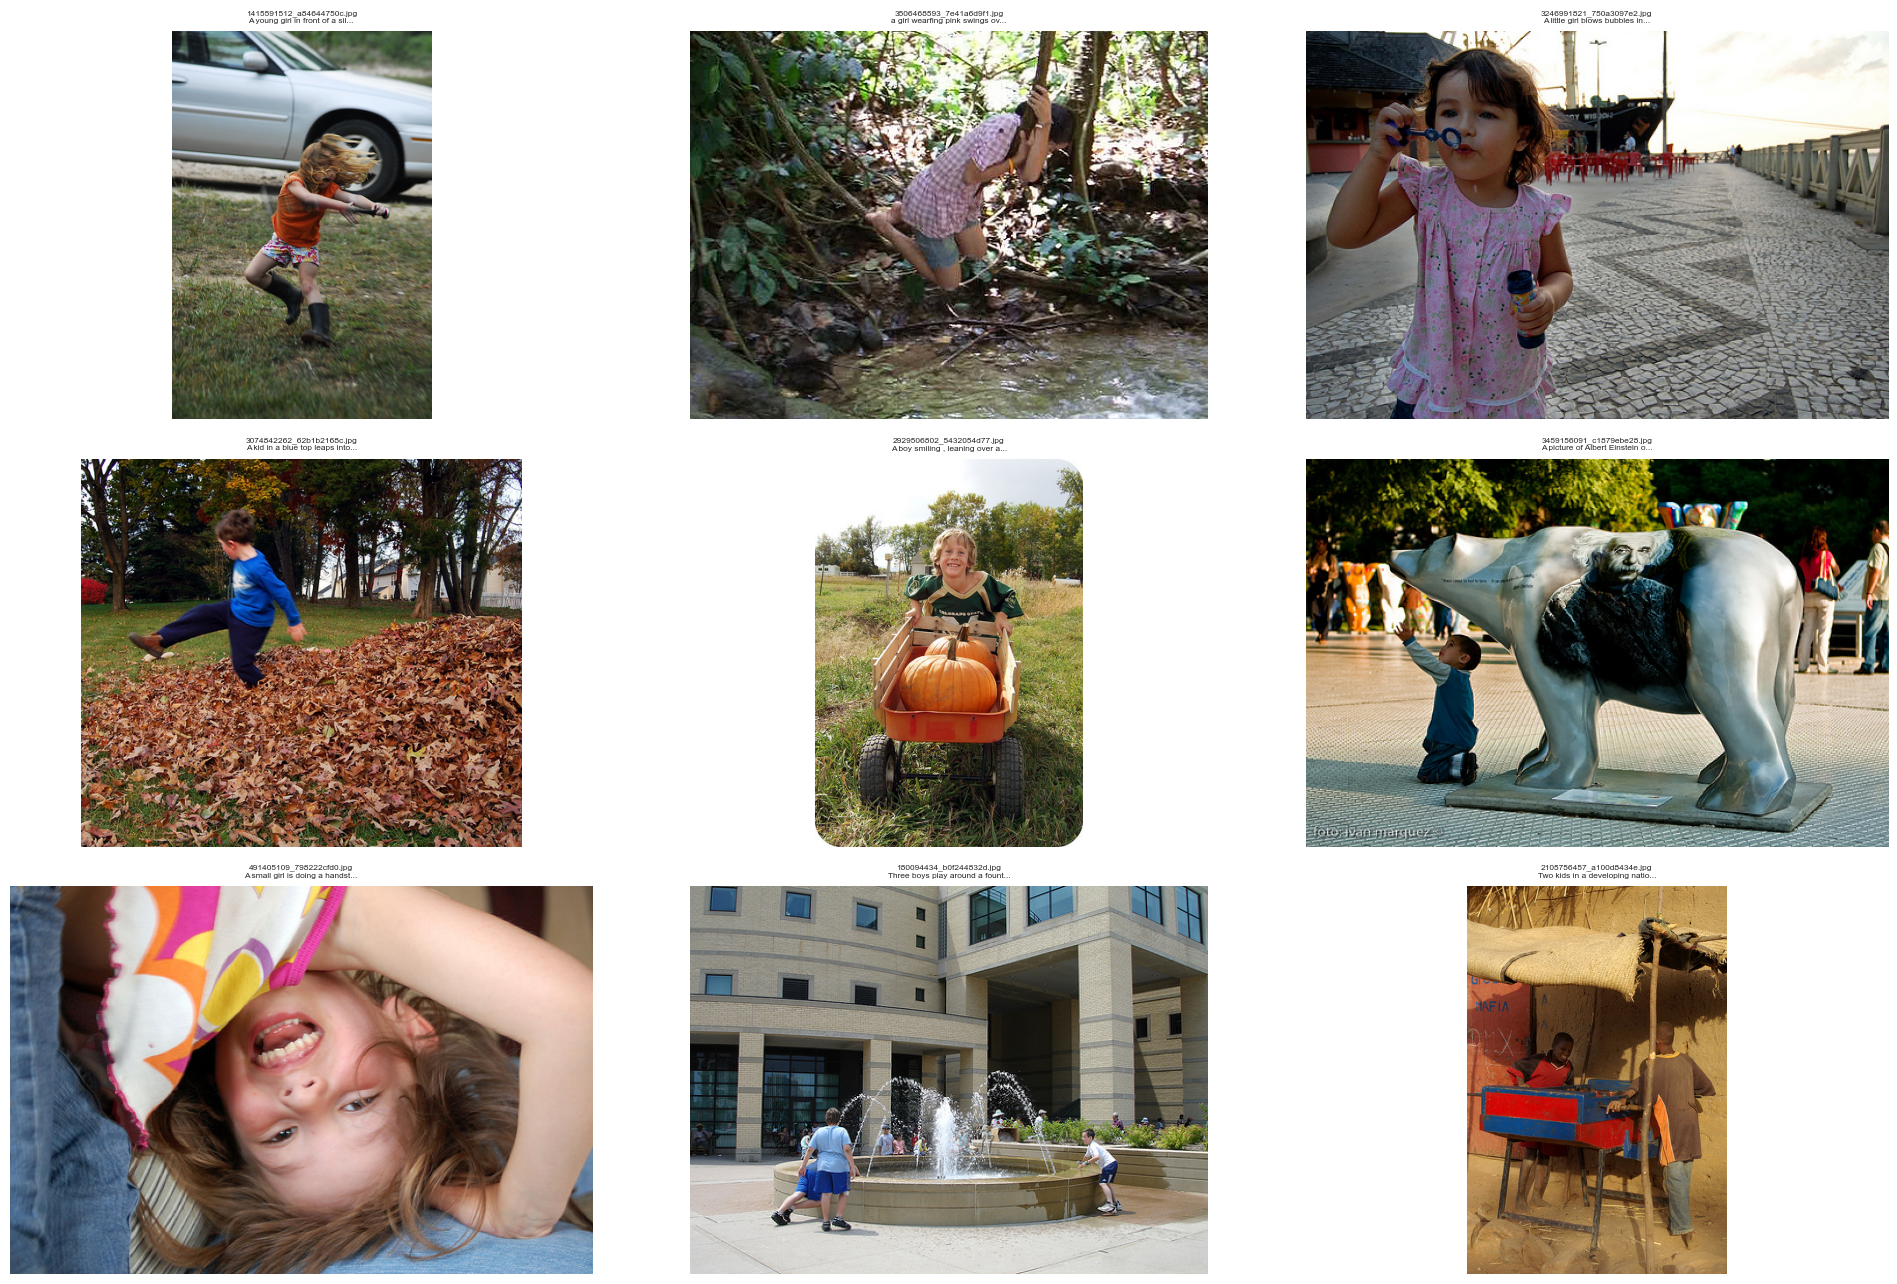

In [43]:
# посмотрим на 9 случайных картинок
deleted_images_list = list(deleted_images)
random_bad_images = random.sample(deleted_images_list, min(9, len(deleted_images_list)))

fig, axes = plt.subplots(3, 3, figsize=(20, 13))
axes = axes.flatten()

for i, img_name in enumerate(random_bad_images):
    try:
        # путь к картинкам
        img_path = os.path.join('./data/train_images', img_name)
        img = Image.open(img_path)
        axes[i].imshow(img)

        # приводим пример описания для этой картинки
        bad_text_sample = deleted_rows[deleted_rows['query_id'].str.startswith(img_name)]['query_text'].iloc[0]
        axes[i].set_title(f"{img_name}\n{bad_text_sample[:30]}...", fontsize=6)
        axes[i].axis('off')
    except Exception as e:
        axes[i].text(0.5, 0.5, f"Не удалось\nзагрузить\n{img_name}",
                    ha='center', va='center', transform=axes[i].transAxes, fontsize=8)
        axes[i].set_title(f"Ошибка загрузки изображения", fontsize=8)
        axes[i].axis('off')

plt.tight_layout()
plt.show()

In [44]:
for i, img_name in enumerate(random_bad_images, 1):
    print(f"{i}. Изображение: {img_name}")
    img_data = deleted_rows[deleted_rows['query_id'].str.startswith(img_name)]
    unique_comments = img_data.drop_duplicates(subset=['query_text'])

    for j, (idx, row) in enumerate(unique_comments.iterrows(), 1):
        print(f"   Текстовое описание: {row['query_text']}")

1. Изображение: 1415591512_a84644750c.jpg
   Текстовое описание: A young girl in front of a silver car wearing boots , demonstrates some interesting moves .
2. Изображение: 3506468593_7e41a6d9f1.jpg
   Текстовое описание: a girl wearfing pink swings over a creek .
3. Изображение: 3246991821_750a3097e2.jpg
   Текстовое описание: A little girl blows bubbles in a courtyard with a ship in the background .
4. Изображение: 3074842262_62b1b2168c.jpg
   Текстовое описание: A kid in a blue top leaps into a raked pile of leaves in front of trees .
5. Изображение: 2929506802_5432054d77.jpg
   Текстовое описание: A boy smiling , leaning over a wagon filled with two large pumpkins .
6. Изображение: 3459156091_c1879ebe28.jpg
   Текстовое описание: A picture of Albert Einstein on a white bear statue , with a little boy standing under the bear statue 's face .
7. Изображение: 491405109_798222cfd0.jpg
   Текстовое описание: A small girl is doing a handstand while smiling
8. Изображение: 180094434_b0f24

Фильтр работает.

In [45]:
# финальная фильтрация датасета
df_final = df_train_clean[~df_train_clean['image'].isin(deleted_images)].copy()

print(f"Итоговый размер чистого датасета для обучения: {df_final.shape}")
print(f"Удалено строк: {len(df_train_clean) - len(df_final)}")

Итоговый размер чистого датасета для обучения: (35892, 4)
Удалено строк: 14322


In [46]:
df_final.info()

<class 'pandas.DataFrame'>
Index: 35892 entries, 0 to 51322
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image       35892 non-null  str    
 1   query_id    35892 non-null  str    
 2   query_text  35892 non-null  str    
 3   target      35892 non-null  float64
dtypes: float64(1), str(3)
memory usage: 1.4 MB


In [47]:
df_final.head()

,image,query_id,query_text,target
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,"A woman is signaling is to traffic , as seen f...",1.0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,A boy in glasses is wearing a red shirt .,0.0
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,A young boy holds onto a blue handle on a pier .,0.0
3,1056338697_4f7d7ce270.jpg,2073964624_52da3a0fc4.jpg#2,"A woman wearing black clothes , a purple scarf...",0.0
4,1056338697_4f7d7ce270.jpg,2083434441_a93bc6306b.jpg#2,An older woman with blond hair rides a bicycle...,0.0


Теперь перейдем к векторизации текста

In [48]:
# инициализация
model_bert, tokenizer_bert = get_bert_extractor(device)

# получение эмбеддингов
embeddings, ids = get_text_embeddings(
    df=df_final,
    model=model_bert,
    tokenizer=tokenizer_bert,
    device=device,
    cache_prefix='train'
)

Готово. Сохранено в train_embs.pt


In [49]:
model_img, transform_img = get_resnet_extractor(device=device)

image_embeddings, image_file_names = get_image_embeddings(
    image_dir="data/train_images",
    model=model_img,
    transform=transform_img,
    device=device,
    cache_prefix="train"  # файлы сохранятся как train_embs.pt
)

In [50]:
image_embeddings_np = image_embeddings.cpu().numpy()

#  удаление дублей в эмбеддингах изображений
unique_image_file_names, unique_image_indices = np.unique(image_file_names, return_index=True)
unique_image_embeddings = image_embeddings_np[unique_image_indices]
unique_image_names_list = list(unique_image_file_names)

#  удаление дублей в эмбеддингах текстов
if isinstance(embeddings, torch.Tensor):
    text_embeddings_np = embeddings.detach().cpu().numpy()
else:
    text_embeddings_np = embeddings

query_ids_array = np.array(ids)

unique_query_ids, unique_text_indices = np.unique(query_ids_array, return_index=True)
unique_text_embeddings = text_embeddings_np[unique_text_indices]
unique_query_ids_list = list(unique_query_ids)

# сопоставление
img_name_to_idx = {name: idx for idx, name in enumerate(unique_image_names_list)}
query_id_to_idx = {qid: idx for idx, qid in enumerate(unique_query_ids_list)}

#  маппинг
try:
    image_indices = [img_name_to_idx[img_name] for img_name in df_final['image']]
    filtered_image_embeddings = unique_image_embeddings[image_indices]

    text_indices = [query_id_to_idx[qid] for qid in df_final['query_id']]
    filtered_text_embeddings = unique_text_embeddings[text_indices]
except KeyError as e:
    print(f"ОШИБКА: Не найдено соответствие для ключа: {e}")
    print("Проверьте, что все image и query_id из df_final есть в загруженных файлах.")
    raise e

# нормализуем изображения
normalizer_img = Normalizer(norm='l2')
filtered_image_embeddings_norm = normalizer_img.fit_transform(filtered_image_embeddings)

# нормализуем тексты
normalizer_txt = Normalizer(norm='l2')
filtered_text_embeddings_norm = normalizer_txt.fit_transform(filtered_text_embeddings)

#  объединение эмбеддингов
combined_features = np.hstack([filtered_image_embeddings_norm, filtered_text_embeddings_norm])

#  добавление целевой переменной
target = df_final['target'].values

# проверяем соответствие размеров
assert combined_features.shape[0] == target.shape[0], "Размеры признаков и целевой переменной не совпадают"

print(f"Данные  объединены. Размер признаков: {combined_features.shape}, Целевая переменная: {target.shape}")

Данные  объединены. Размер признаков: (35892, 1280), Целевая переменная: (35892,)


In [51]:
# проверка на наличие NaN
contains_nan = np.isnan(combined_features).any()
print(f"Содержатся ли NaN значения в combined_features: {contains_nan}")

# проверка на наличие Inf или -Inf
contains_inf = np.isinf(combined_features).any()
print(f"Содержатся ли Inf значения в combined_features: {contains_inf}")

# итоговая проверка на отсутствие некорректных данных
if contains_nan or contains_inf:
    print("В массиве combined_features есть некорректные значения")
else:
    print("Все значения в массиве combined_features корректны.")

Содержатся ли NaN значения в combined_features: False
Содержатся ли Inf значения в combined_features: False
Все значения в массиве combined_features корректны.


# Обучение моделей

In [52]:
# разобъем данные на тренировочную и валидационную выборки
gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=RANDOM_STATE)

# используем image в качестве групп для разбиения
train_ind, valid_ind = next(gss.split(X=combined_features, y=target, groups=df_final['image']))

X_train, X_valid = combined_features[train_ind], combined_features[valid_ind]
y_train, y_valid = target[train_ind], target[valid_ind]

print(f"Тренировочная выборка: {len(X_train)} записей, валидационная выборка: {len(X_valid)} записей.")

Тренировочная выборка: 25012 записей, валидационная выборка: 10880 записей.


In [53]:
# проверка, что изображения не пересекаются
train_images_set = set(df_final.iloc[train_ind]['image'])
valid_images_set = set(df_final.iloc[valid_ind]['image'])
intersection = train_images_set.intersection(valid_images_set)
assert len(intersection) == 0, "ОШИБКА: Изображения пересекаются между Train и Valid!"
print("Проверка пройдена: изображения в Train и Valid не пересекаются.")

Проверка пройдена: изображения в Train и Valid не пересекаются.


## Модель 1: Линейная регрессия (Baseline)

In [54]:
# инициализация модели линейной регрессии
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_valid)

# RMSE на валидационной
rmse_lr = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f"RMSE (валидационная выборка): {rmse_lr:.4f}")

RMSE (валидационная выборка): 0.2401


## Модель 2: Ridge Regression (с подбором гиперпараметров)

In [55]:
gkf = GroupKFold(n_splits=5)

# параметры
param_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

# инициализация модели Ridge
ridge_model = Ridge(random_state=RANDOM_STATE)

# кросс-валидация
grid_search = GridSearchCV(
    estimator=ridge_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=gkf,
    n_jobs=-1,
    verbose=1,
)

groups_train = df_final.iloc[train_ind]['image']

grid_search.fit(X_train, y_train, groups=groups_train)

best_ridge_model = grid_search.best_estimator_

y_pred_valid = best_ridge_model.predict(X_valid)
mse_valid = np.mean((y_valid - y_pred_valid) ** 2)
rmse_valid_r = np.sqrt(mse_valid)

print(f"Лучшие параметры alpha: {grid_search.best_params_}")
print(f"RMSE на валидационных: {rmse_valid_r:.4f}")

Лучшие параметры alpha: {'alpha': 10.0}
RMSE на валидационных: 0.2151


## Модель 3: Полносвязная нейронная сеть

In [56]:
class RegressionNN(nn.Module):
    def __init__(self, input_dim):
        super(RegressionNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)


# настройка параметров и группового разбиения
input_dim = X_train.shape[1]

model = RegressionNN(input_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.BCEWithLogitsLoss()

# конвертация в тензоры
eps = 1e-7
y_train_clamped = np.clip(y_train, eps, 1 - eps)
y_valid_clamped = np.clip(y_valid, eps, 1 - eps)

X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train_clamped).reshape(-1, 1).to(device)

X_valid_tensor = torch.FloatTensor(X_valid).to(device)
y_valid_tensor = torch.FloatTensor(y_valid_clamped).reshape(-1, 1).to(device)
y_valid_original = y_valid

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# early stopping
n_epochs = 100
patience = 10
best_valid_rmse = float('inf')
best_model_state = None
epochs_no_improve = 0

# списки для графиков
train_losses = []
val_rmses = []

# цикл обучения
for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_valid_tensor)

        val_preds_prob = torch.sigmoid(val_outputs).cpu().numpy()

        current_valid_rmse = np.sqrt(mean_squared_error(y_valid_original, val_preds_prob))
        val_rmses.append(current_valid_rmse)

    # логирование каждые 10 эпох
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.4f} | Valid RMSE: {current_valid_rmse:.4f}")

    if current_valid_rmse < best_valid_rmse:
        best_valid_rmse = current_valid_rmse
        best_model_state = model.state_dict().copy() # Сохраняем копию весов
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nРанняя остановка в эпохе {epoch+1}. Лучший RMSE на валидации: {best_valid_rmse:.4f}")
            break

model.load_state_dict(best_model_state)

# финальный расчет на валидации
model.eval()
with torch.no_grad():
    final_preds = torch.sigmoid(model(X_valid_tensor)).cpu().numpy()
    final_rmse = np.sqrt(mean_squared_error(y_valid_original, final_preds))

print(f"Финальный RMSE: {final_rmse:.4f}")


Ранняя остановка в эпохе 31. Лучший RMSE на валидации: 0.2021
Финальный RMSE: 0.2050


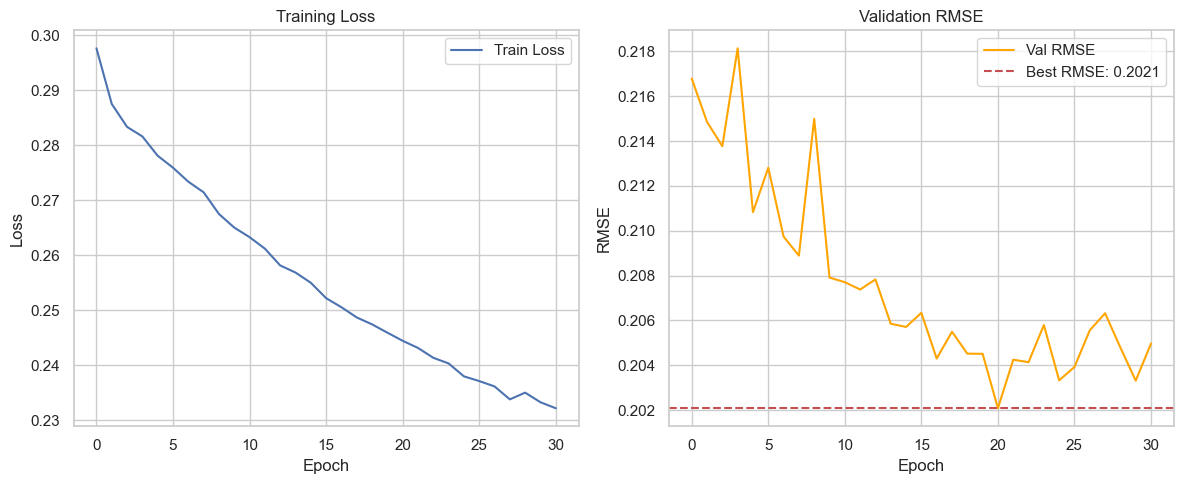

In [57]:
plt.figure(figsize=(12, 5))

# график Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# график RMSE
plt.subplot(1, 2, 2)
plt.plot(val_rmses, label='Val RMSE', color='orange')
plt.axhline(y=best_valid_rmse, color='r', linestyle='--', label=f'Best RMSE: {best_valid_rmse:.4f}')
plt.title('Validation RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [58]:
models = ['Линейная регрессия', 'Ridge Regression', 'Нейросеть (MLP)']
rmse_values = [rmse_lr, rmse_valid_r, final_rmse]
df_results = pd.DataFrame({
    'Модель': models,
    'RMSE': rmse_values
})

df_results = df_results.sort_values(by='RMSE').reset_index(drop=True).round(4)
df_results

,Модель,RMSE
0,Нейросеть (MLP),0.2050
1,Ridge Regression,0.2151
2,Линейная регрессия,0.2401


In [59]:
# определим лучшую модель
final_model = RegressionNN(input_dim).to(device)
final_model.load_state_dict(best_model_state)

<All keys matched successfully>

## Вывод

Было обучено 3 модели:
- Линейная регрессия
- Ridge с подбором гиперпараметров
- Полносвязная нейронная сеть

Лучший результат показала нейронная сеть. Результат тестирования на валидационной выборке показал результат 0.3.

# Тестирование модели на тестовом наборе данных

In [60]:
image_embeddings_test, image_file_names_test = get_image_embeddings(
    image_dir="data/test_images",
    model=model_img,
    transform=transform_img,
    device=device,
    cache_prefix="test"
)

# создаем словарь
test_img_dict = create_image_embedding_dict(image_embeddings_test, image_file_names_test, normalize=True)

In [61]:
# функция для поиска и отображения наиболее похожих изображений по текстовому запросу
def search_and_display(
    model,
    query_text,
    df_test,
    bert_model,
    bert_tokenizer,
    image_emb_dict=test_img_dict,
    device=device,
    banned_words=None,
    images_folder='test_images',
    top_k=4
):
    """
    Выполняет поиск, предсказание через MLP и отображает результаты.
    """
    model.eval()

    # проверка на запрещенные слова
    if banned_words:
        lower_query = query_text.lower()

        is_forbidden = False
        for word in banned_words:
            if word in lower_query:
                is_forbidden = True
                break

        if is_forbidden:
            print(f"Поисковый запрос: '{query_text}'")
            print('This image is unavailable in your country in compliance with local laws.')
            return None

    print(f"Поисковый запрос: '{query_text}'")

    # поиск по тексту
    ground_truth_rows = df_test[df_test['query_text'] == query_text]
    ground_truth_img = ground_truth_rows.iloc[0]['image'] if not ground_truth_rows.empty else None

    # векторизация текста
    text_emb = get_single_text_embedding(query_text, bert_model, bert_tokenizer, device)
    text_emb_np = text_emb.cpu().numpy()
    text_emb_norm = normalize(text_emb_np, norm='l2')
    text_vector = torch.from_numpy(text_emb_norm).to(device)

    # подготовка данных
    all_img_names = list(image_emb_dict.keys())

    # создаем тензор текстовых векторов
    n_images = len(all_img_names)
    text_matrix = text_vector.repeat(n_images, 1) # [N, 768]

    # создаем тензор изображений из словаря
    img_vectors_list = [image_emb_dict[name] for name in all_img_names]
    img_matrix_np = np.stack(img_vectors_list)

    img_matrix = torch.from_numpy(img_matrix_np).float().to(device)

    # конкатенация
    combined_input = torch.cat([text_matrix, img_matrix], dim=1)

    # предсказание
    with torch.no_grad():
        scores = model(combined_input).cpu().numpy().flatten()

    # ранжирование
    scored_images = list(zip(scores, all_img_names))

    scored_images.sort(key=lambda x: x[0], reverse=True)

    top_predictions = scored_images[:top_k]

    # визуализация

    total_cols = top_k + (1 if ground_truth_img else 0)
    if total_cols == 0: return

    fig = plt.figure(figsize=(4 * total_cols, 6))
    col_idx = 0

    if ground_truth_img:
        ax_gt = fig.add_subplot(1, total_cols, col_idx + 1)
        gt_path = os.path.join(images_folder, ground_truth_img)
        try:
            img_gt = Image.open(gt_path)
            ax_gt.imshow(img_gt)
            ax_gt.set_title(f"Ground Truth:\n{ground_truth_img}", fontsize=11, color='green')
            ax_gt.axis('off')
        except Exception:
            ax_gt.text(0.5, 0.5, "Img Error", ha='center', va='center', color='red')
            ax_gt.axis('off')
        col_idx += 1

    for i, (score, img_name) in enumerate(top_predictions):
        ax = fig.add_subplot(1, total_cols, col_idx + i + 1)
        img_path = os.path.join(images_folder, img_name)
        try:
            img = Image.open(img_path)
            ax.imshow(img)
            rank = i + 1
            # Подсветка зеленым, если предсказание совпало с Ground Truth
            color = 'green' if (ground_truth_img and img_name == ground_truth_img) else 'black'
            title = f"#{rank} | {score:.3f}\n{img_name}"
            ax.set_title(title, fontsize=10, color=color)
            ax.axis('off')
        except Exception:
            ax.text(0.5, 0.5, "Img Error", ha='center', va='center', color='red')
            ax.axis('off')

    plt.suptitle(f"Query: \"{query_text}\"", fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()

    # вывод
    print("\nРезультаты:")
    if ground_truth_img:
        print(ground_truth_img)

    print(f"ТОП предсказаний:")
    for i, (score, img_name) in enumerate(top_predictions, 1):
        marker = " <-- MATCH!" if (ground_truth_img and img_name == ground_truth_img) else ""
        print(f"{i}. {img_name} | Score: {score:.4f}{marker}")

    return top_predictions

In [63]:
# берём 20 случайных запросов из final_test_queries
random_queries = df_test['query_text'].drop_duplicates().sample(n=20, random_state=RANDOM_STATE).tolist()

for query in random_queries:
    result = search_and_display(
        model=final_model,
        query_text=query,
        df_test=df_test,
        bert_model=model_bert,
        bert_tokenizer=tokenizer_bert,
        image_emb_dict=test_img_dict,
        device=device,
        banned_words=restricted_words,
        images_folder="data/test_images",
        top_k=5
    )
    print()


Результаты:
3396275223_ee080df8b5.jpg
ТОП предсказаний:
1. 3455405300_aa3069ecaa.jpg | Score: 1.2325
2. 989851184_9ef368e520.jpg | Score: 1.1412
3. 2428094795_d3a8f46046.jpg | Score: 1.0999
4. 3653484549_f316590b0f.jpg | Score: 1.0979
5. 3488087117_2719647989.jpg | Score: 1.0892

Поисковый запрос: 'The girl is blowing out the candles on the chocolate cake .'
This image is unavailable in your country in compliance with local laws.



## Вывод

- Из тестового датасета удален запрещенный контент
- Рассчитаны эмбеддинги для текстов и изображений
- Создана функция принимающая на вход текстовое описание и выдающая релевантное изображение
- Визуальный анализ изображений полученные в итоге по запросу дали оочень низкое качество

# Вывод

## Загрузка данных

Данные загружены, пропусков и дубликатов нет. Данные соответствуют описанию. Был сформирован общий тренировочный датафрейм (объединены данные).

## Исследовательский анализ данных

1. Экспертные оценки:
- Смещение в сторону "1": Все три эксперта чаще всего ставят оценку 1.
- Разногласия: Только 2.16% строк имеют полное разногласие. Это мало, поэтому мы смело можем удалить эти строки, не теряя много данных.
- Согласованность: В примерно 58% случаев эксперты полностью согласны. Это хороший знак надежности данных.
2. Краудсорсинговые оценки:
- Средняя доля согласия (ratio) всего 0.07, а медиана 0.00. Это значит, что в подавляющем большинстве случаев люди считали, что текст не соответствует картинке.

## Подготовка данных и обучение модели

Было обучено 3 модели:
- Линейная регрессия
- Ridge с подбором гиперпараметров
- Полносвязная нейронная сеть

Лучший результат показала нейронная сеть. Результат тестирования на валидационной выборке показал результат 0.29.

## Тестирование модели на тестовом наборе данных

- Из тестового датасета удален запрещенный контент
- Рассчитаны эмбеддинги для текстов и изображений
- Создана функция принимающая на вход текстовое описание и выдающая подходящее изображение
- Визуальный анализ изображений полученные в итоге по запросу дали оочень низкое качество